# Question 7 (10 Marks) — Test Accuracy + Creative Confusion Matrix
For the best model (Adam, [128,128,128], ReLU, Xavier, 20 epochs, wd=0.0005),
report test accuracy and plot the confusion matrix.

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
import tensorflow as tf
from neural_network import NeuralNetwork

CLASS_NAMES = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

# ── Load data ──────────────────────────────────────────────────────────
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.reshape(-1, 784) / 255.0
X_test       = X_test.reshape(-1, 784) / 255.0

val_size = int(0.1 * len(X_train_full))
X_val,   y_val   = X_train_full[-val_size:], y_train_full[-val_size:]
X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]

print('Data loaded.')

Data loaded.


In [3]:
# ── Train best model ──────────────────────────────────────────────────
print('Training best model...')
best = NeuralNetwork(
    hidden_layers=[128, 128, 128],
    activation='relu',
    weight_init='xavier',
)
best.train(
    X_train, y_train,
    epochs=20, learning_rate=1e-3,
    batch_size=64, optimizer='adam',
    weight_decay=0.0005, verbose=True,
)

test_acc = best.accuracy(X_test, y_test)
val_acc  = best.accuracy(X_val,  y_val)
print(f'\n✅ Val  Accuracy : {val_acc*100:.2f}%')
print(f'✅ Test Accuracy : {test_acc*100:.2f}%')

Training best model...
Epoch   0 | Loss: 0.3722
Epoch   5 | Loss: 0.3171
Epoch  10 | Loss: 0.2581
Epoch  15 | Loss: 0.2495
Epoch  19 | Loss: 0.2248

✅ Val  Accuracy : 88.60%
✅ Test Accuracy : 87.96%


In [4]:
# ── Build confusion matrix ─────────────────────────────────────────────
y_pred = best.predict(X_test)

n = 10
cm = np.zeros((n, n), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[true][pred] += 1

# Normalise to percentages (row-wise)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print('Confusion matrix (raw counts):')
print(cm)

Confusion matrix (raw counts):
[[807   2   4  27   6   0 144   0  10   0]
 [  3 971   2  18   4   0   1   0   1   0]
 [ 16   1 680  15 186   1 100   0   1   0]
 [ 19   8   7 901  36   0  25   1   3   0]
 [  0   1  39  31 883   0  45   0   1   0]
 [  0   0   0   1   0 943   0  28   1  27]
 [ 98   2  45  33  99   0 719   0   4   0]
 [  0   0   0   0   0   7   0 970   0  23]
 [  5   1   3   2   8   2   6   5 968   0]
 [  0   0   0   0   0   7   1  38   0 954]]


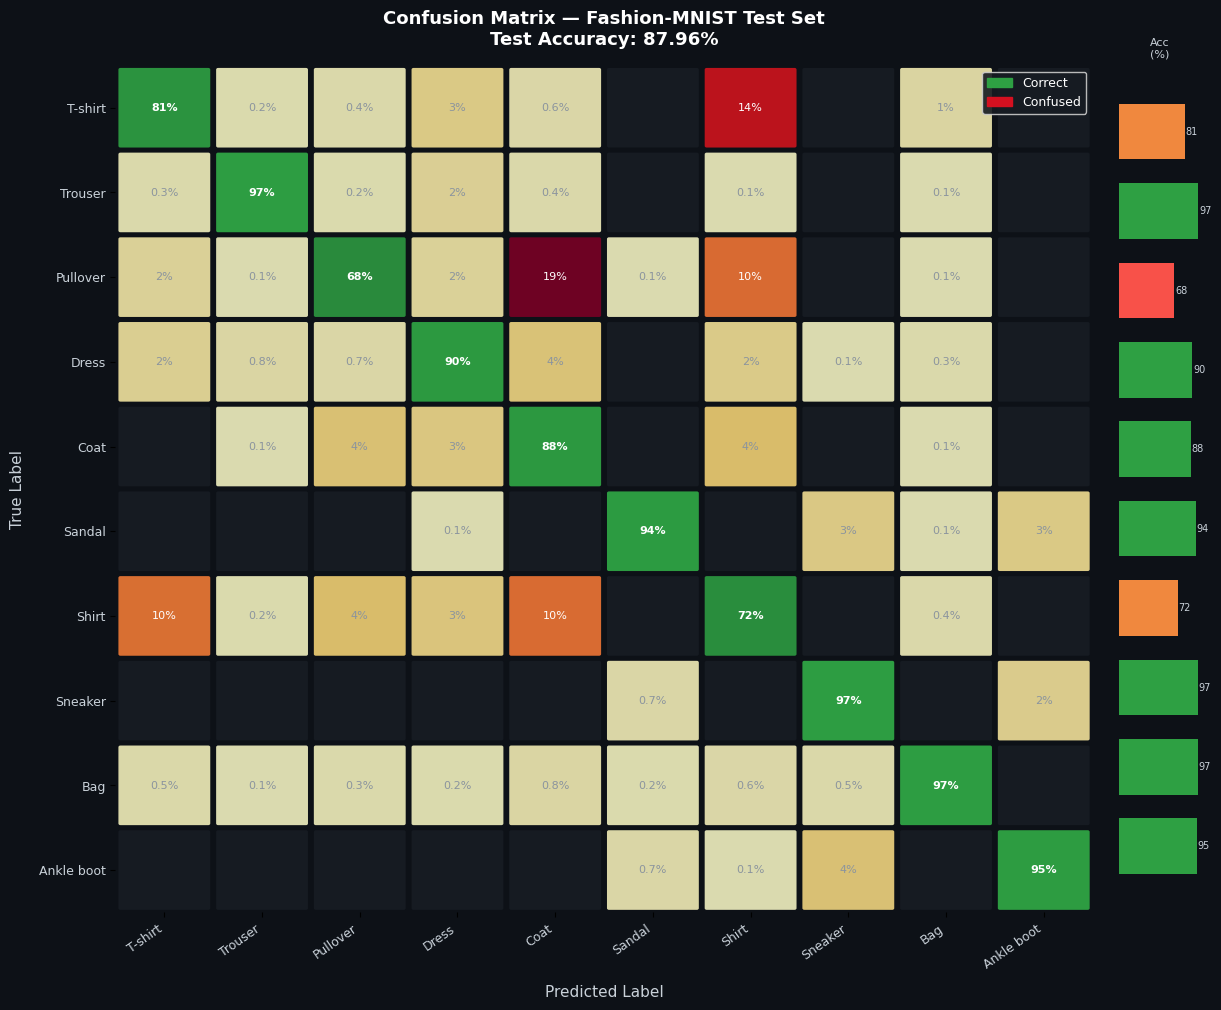

✅ Q7 confusion matrix saved as q7_confusion_matrix.png


In [5]:
# ── Creative Confusion Matrix Plot ───────────────────────────────────
# Design: dark background, diagonal highlighted in green,
#         off-diagonal errors in warm coral, per-class accuracy bar on right.

fig = plt.figure(figsize=(14, 11), facecolor='#0d1117')
gs  = fig.add_gridspec(1, 2, width_ratios=[12, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0])
axb = fig.add_subplot(gs[1])

ax.set_facecolor('#0d1117')
axb.set_facecolor('#0d1117')

# ── Draw cells ────────────────────────────────────────────────────────
DIAG_COLOR  = '#2ea043'   # GitHub green for correct
ERROR_CMAP  = plt.cm.YlOrRd

max_off = cm_norm[~np.eye(n, dtype=bool)].max()

for i in range(n):
    for j in range(n):
        val = cm_norm[i, j]
        if i == j:
            color = DIAG_COLOR
            alpha = 0.55 + 0.45 * (val / 100)
        else:
            if val == 0:
                color = '#161b22'
                alpha = 1.0
            else:
                color = mcolors.to_hex(ERROR_CMAP(val / (max_off + 1e-6)))
                alpha = 0.85
        rect = FancyBboxPatch(
            (j + 0.05, n - i - 1 + 0.05), 0.90, 0.90,
            boxstyle='round,pad=0.02', linewidth=0,
            facecolor=color, alpha=alpha,
        )
        ax.add_patch(rect)
        if val > 0:
            txt_color = 'white' if (i == j or val > max_off * 0.5) else '#8b949e'
            ax.text(j + 0.5, n - i - 0.5,
                    f'{val:.0f}%' if val >= 1 else f'{val:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color=txt_color, fontweight='bold' if i == j else 'normal')

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(0, n); ax.set_ylim(0, n)
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', color='#c9d1d9', fontsize=9)
ax.set_yticklabels(CLASS_NAMES[::-1], color='#c9d1d9', fontsize=9)
ax.set_xlabel('Predicted Label', color='#c9d1d9', fontsize=11, labelpad=10)
ax.set_ylabel('True Label',      color='#c9d1d9', fontsize=11, labelpad=10)
ax.set_title(
    f'Confusion Matrix — Fashion-MNIST Test Set\nTest Accuracy: {test_acc*100:.2f}%',
    color='white', fontsize=13, fontweight='bold', pad=15
)
for sp in ax.spines.values(): sp.set_visible(False)

# ── Per-class accuracy bar (right sidebar) ────────────────────────────
per_class_acc = np.diag(cm_norm)
bar_colors = [DIAG_COLOR if a >= 85 else '#f0883e' if a >= 70 else '#f85149'
              for a in per_class_acc]
axb.barh(
    np.arange(n), per_class_acc[::-1],
    color=bar_colors[::-1], height=0.7, left=0
)
axb.set_xlim(0, 100)
axb.set_yticks([]); axb.set_xticks([])
axb.set_title('Acc\n(%)', color='#c9d1d9', fontsize=8)
for sp in axb.spines.values(): sp.set_visible(False)
for i, a in enumerate(per_class_acc[::-1]):
    axb.text(a + 1, i, f'{a:.0f}', va='center', color='#c9d1d9', fontsize=7)

# ── Legend ────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=DIAG_COLOR, label='Correct'),
    mpatches.Patch(color=ERROR_CMAP(0.8), label='Confused'),
]
ax.legend(handles=handles, loc='upper right',
          facecolor='#161b22', labelcolor='white', fontsize=9,
          framealpha=0.9)

plt.savefig('q7_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Q7 confusion matrix saved as q7_confusion_matrix.png')

In [6]:
# ── Per-class breakdown ────────────────────────────────────────────────
print(f'{'Class':<14}  Accuracy  Most-confused-with')
print('-' * 55)
for i, name in enumerate(CLASS_NAMES):
    row   = cm_norm[i].copy()
    top_wrong_idx = np.argsort(row)[::-1]
    top_wrong = [(CLASS_NAMES[j], f'{row[j]:.1f}%') for j in top_wrong_idx if j != i][:2]
    print(f'{name:<14}  {row[i]:5.1f}%   {top_wrong[0][0]} ({top_wrong[0][1]}), {top_wrong[1][0]} ({top_wrong[1][1]})')

Class           Accuracy  Most-confused-with
-------------------------------------------------------
T-shirt          80.7%   Shirt (14.4%), Dress (2.7%)
Trouser          97.1%   Dress (1.8%), Coat (0.4%)
Pullover         68.0%   Coat (18.6%), Shirt (10.0%)
Dress            90.1%   Coat (3.6%), Shirt (2.5%)
Coat             88.3%   Shirt (4.5%), Pullover (3.9%)
Sandal           94.3%   Sneaker (2.8%), Ankle boot (2.7%)
Shirt            71.9%   Coat (9.9%), T-shirt (9.8%)
Sneaker          97.0%   Ankle boot (2.3%), Sandal (0.7%)
Bag              96.8%   Coat (0.8%), Shirt (0.6%)
Ankle boot       95.4%   Sneaker (3.8%), Sandal (0.7%)
